# KAN as feature selector

In [1]:
import os
import torch
import numpy as np
import pandas as pd
from kan import KAN, ex_round
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

fold_path = "/home/alecacciatore/rolex/ECML26/GNN4eGFR"
out_path = os.path.join(fold_path, "features_importance_score/kan_scores")
file_path = os.path.join(fold_path, "XY_temp.csv")
file_updated_path = os.path.join(fold_path, "XY_temp_updated.csv")
file_no_temp_path = os.path.join(fold_path, "XY_no_temp_updated.csv")

if not os.path.exists(out_path):
    os.makedirs(out_path)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
df_no_temp_updated = pd.read_csv(file_no_temp_path)
df_ = df_no_temp_updated

# for idx, row in df.iterrows():
for col in df_.columns:
    nan = df_[col].isnull().sum().sum()
    if nan > 0:
        print(f"Nan in column {col}", nan, f"over {len(df_[col])}")

Nan in column 053.9_icd9 52 over 1833
Nan in column 239.9_icd9 52 over 1833
Nan in column 245.2_icd9 52 over 1833
Nan in column 250.00_icd9 52 over 1833
Nan in column 250.0_icd9 52 over 1833
Nan in column 272.0_icd9 52 over 1833
Nan in column 274.9_icd9 52 over 1833
Nan in column 285.9_icd9 52 over 1833
Nan in column 365.9_icd9 52 over 1833
Nan in column 389.9_icd9 52 over 1833
Nan in column 401.9_icd9 52 over 1833
Nan in column 427.31_icd9 52 over 1833
Nan in column 460_icd9 52 over 1833
Nan in column 461.9_icd9 52 over 1833
Nan in column 462_icd9 52 over 1833
Nan in column 463_icd9 52 over 1833
Nan in column 464.0_icd9 52 over 1833
Nan in column 464.1_icd9 52 over 1833
Nan in column 465.9_icd9 52 over 1833
Nan in column 466.0_icd9 52 over 1833
Nan in column 521.0_icd9 52 over 1833
Nan in column 530.81_icd9 52 over 1833
Nan in column 553.3_icd9 52 over 1833
Nan in column 558.9_icd9 52 over 1833
Nan in column 595.0_icd9 52 over 1833
Nan in column 595.9_icd9 52 over 1833
Nan in column 6

## Get data

In [3]:
# read the CSV file into a DataFrame
df = pd.read_csv(file_no_temp_path)

# remove icd9 columns
cols_ok = [col for col in df.columns[:-2] if not 'icd9' in col]

# the last column is the target variable and the first one is an indppex
y_classif = df.iloc[:, -1]
y_regress = df.iloc[:, -2]

# X columns
X_no_icd9 = df[cols_ok]
print(X_no_icd9.shape, f"with {X_no_icd9.isnull().sum().sum()} missing values")
X = df.iloc[:, 1:-3] # TODO: include general practitioner features?
print(X.shape, f"with {X.isnull().sum().sum()} missing values")
X = X.fillna(X.mean())
print(X.shape, f"with {X.isnull().sum().sum()} missing values")

# y_classif contains [I, II, IIIa, IIIb, IV, V] labels
# label_mapping = {'I': 0, 'II': 1, 'IIIa': 2, 'IIIb': 3, 'IV': 4, 'V': 5}
label_mapping = {'I': 0, 'II': 1, 'IIIa': 1, 'IIIb': 1, 'IV': 1, 'V': 1}
y_classif = y_classif.map(label_mapping)

# Split data into training and testing sets
X_train, X_test, y_classif_train, y_classif_test = train_test_split(
    X, y_classif, test_size=0.2, random_state=42, stratify=y_classif
)
X_train_reg, X_test_reg, y_regress_train, y_regress_test = train_test_split(
    X, y_regress, test_size=0.2, random_state=42
)

# Create a dataset dictionary for KAN ('test_input', 'test_label', 'train_input', 'train_label')
train_data_classif = {
    'train_input': torch.tensor(X_train.values, dtype=torch.float32).to(device),
    'train_label': torch.tensor(y_classif_train.values, dtype=torch.long).to(device),
    'test_input': torch.tensor(X_test.values, dtype=torch.float32).to(device),
    'test_label': torch.tensor(y_classif_test.values, dtype=torch.long).to(device)
}
train_data_regress = {
    'train_input': torch.tensor(X_train_reg.values, dtype=torch.float32).to(device),
    'train_label': torch.tensor(y_regress_train.values, dtype=torch.float32).to(device),
    'test_input': torch.tensor(X_test_reg.values, dtype=torch.float32).to(device),
    'test_label': torch.tensor(y_regress_test.values, dtype=torch.float32).to(device)
}

(1833, 498) with 0 missing values
(1833, 539) with 2236 missing values
(1833, 539) with 0 missing values


In [4]:
# print per-class distribution and imbalance ratio
class_counts = y_classif_train.value_counts().sort_index()
imbalance_ratio = class_counts.max() / class_counts.min()
print("Class distribution in training set:")
for cls, count in class_counts.items():
    print(f"Class {cls}: {count} samples")
print(f"Imbalance Ratio: {imbalance_ratio:.2f}")

# Resample (SMOTE)
# smote = SMOTE(random_state=42)
# X, y_classif = smote.fit_resample(X, y_classif)

# # New imbalance ratio
# value_counts_resampled = y_classif.value_counts()
# imbalance_ratio_resampled = value_counts_resampled.max() / value_counts_resampled.min()
# print(f"Imbalance ratio after SMOTE: {imbalance_ratio_resampled}")


Class distribution in training set:
Class 0: 264 samples
Class 1: 1202 samples
Imbalance Ratio: 4.55


## Train KAN classifier

In [5]:
print("Training KAN Classifier...")
kan_classifier = KAN(width=[train_data_classif['train_input'].shape[1], 2, 2], grid=3, k=3, device=device, ckpt_path=out_path)
# kan_classifier.speed()

def train_acc():
    return torch.mean((torch.argmax(kan_classifier(train_data_classif['train_input']), dim=1) == train_data_classif['train_label']).type(torch.float32))

def test_acc():
    return torch.mean((torch.argmax(kan_classifier(train_data_classif['test_input']), dim=1) == train_data_classif['test_label']).type(torch.float32))

results = kan_classifier.fit(train_data_classif, opt="LBFGS", steps=10, metrics=(train_acc, test_acc),
                             loss_fn=torch.nn.CrossEntropyLoss(), )
print("Training completed."
      f"\nFinal Train Accuracy: {results['train_acc'][-1]:.4f}"
      f"\nFinal Test Accuracy: {results['test_acc'][-1]:.4f}")

Training KAN Classifier...
checkpoint directory created: /home/alecacciatore/rolex/ECML26/GNN4eGFR/features_importance_score/kan_scores
saving model version 0.0


description:   0%|                                                           | 0/10 [00:00<?, ?it/s]

| train_loss: 6.54e-01 | test_loss: 6.70e-01 | reg: 4.23e+01 | : 100%|█| 10/10 [00:18<00:00,  1.83s/

saving model version 0.1
Training completed.
Final Train Accuracy: 0.8179
Final Test Accuracy: 0.8229


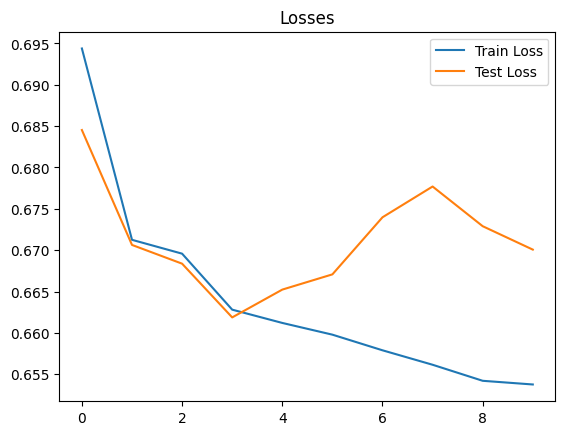

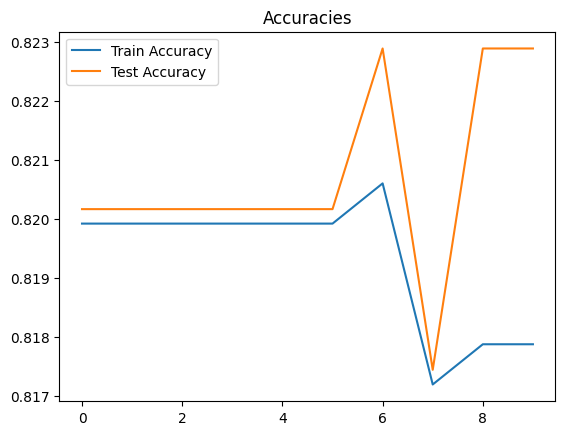

In [6]:
import matplotlib.pyplot as plt

plt.figure()
plt.title("Losses")
plt.plot(results['train_loss'], label='Train Loss')
plt.plot(results['test_loss'], label='Test Loss')
plt.legend()
plt.show()

plt.figure()
plt.title("Accuracies")
plt.plot(results['train_acc'], label='Train Accuracy')
plt.plot(results['test_acc'], label='Test Accuracy')
plt.legend()
plt.show()

## Prune KAN classifier

In [7]:
import copy

node_th = 1e-2
edge_th = 1e-2
pruned_test_acc = test_acc()
pruned_test_acc_old = 0

kan_pruned_ = copy.deepcopy(kan_classifier)

for incr in [1e-2, 1e-3, 1e-4]:
    print("Increasing thresholds by", incr)
    start = True
    while start:
        print(f"Pruning with node_th {node_th:.4f} and edge_th {edge_th:.4f}...")

        # prune the network
        kan_pruned_ = kan_pruned_.prune(node_th=node_th, edge_th=edge_th)

        # test the pruned network
        pruned_train_acc = torch.mean((torch.argmax(kan_pruned_(train_data_classif['train_input']), dim=1) == train_data_classif['train_label']).type(torch.float32))
        pruned_test_acc_ = torch.mean((torch.argmax(kan_pruned_(train_data_classif['test_input']), dim=1) == train_data_classif['test_label']).type(torch.float32))
        
        print(f"\tCurrent train accuracy {pruned_train_acc:.2f} ({pruned_train_acc/train_acc()*100:.2f} of initial value)")
        print(f"\tCurrent test accuracy {pruned_test_acc_:.2f} ({pruned_test_acc_/test_acc()*100:.2f} of initial value)\n")

        if pruned_test_acc_ / test_acc() >= 0.96:
            node_th += incr
            edge_th += incr
            pruned_test_acc_old = pruned_test_acc_
            pruned_test_acc = pruned_test_acc_
            kan_pruned = kan_pruned_
        else:
            pruned_test_acc_old = pruned_test_acc_old
            start = False

RuntimeError: Only Tensors created explicitly by the user (graph leaves) support the deepcopy protocol at the moment.  If you were attempting to deepcopy a module, this may be because of a torch.nn.utils.weight_norm usage, see https://github.com/pytorch/pytorch/pull/103001

In [20]:
print(torch.mean((torch.argmax(kan_pruned(train_data_classif['train_input']), dim=1) == train_data_classif['train_label']).type(torch.float32)))
print(torch.mean((torch.argmax(kan_pruned(train_data_classif['test_input']), dim=1) == train_data_classif['test_label']).type(torch.float32)))

tensor(0.8199)
tensor(0.8202)


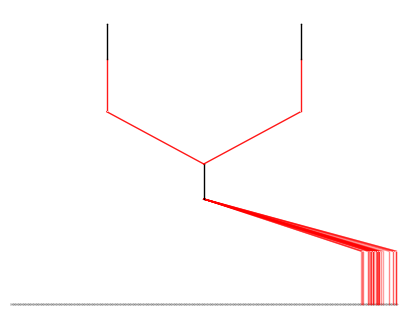

In [206]:
kan_pruned.plot()

# Symbolic regression

In [ ]:
lib = ['x','x^2','x^3','x^4','exp','log','sqrt','tanh','sin','tan','abs']
kan_pruned.auto_symbolic(lib=lib)
formula1 = kan_pruned.symbolic_formula()[0][0]
formula2 = kan_pruned.symbolic_formula()[0][1]
# ex_round(formula1, 4)

fixing (0,0,0) with 0
fixing (0,1,0) with 0
fixing (0,2,0) with 0
fixing (0,3,0) with 0
fixing (0,4,0) with 0
fixing (0,5,0) with 0
fixing (0,6,0) with 0
fixing (0,7,0) with 0
fixing (0,8,0) with 0
fixing (0,9,0) with 0
fixing (0,10,0) with 0
fixing (0,11,0) with 0
fixing (0,12,0) with 0
fixing (0,13,0) with 0
fixing (0,14,0) with 0
fixing (0,15,0) with 0
fixing (0,16,0) with 0
fixing (0,17,0) with 0
fixing (0,18,0) with 0
fixing (0,19,0) with 0
fixing (0,20,0) with 0
fixing (0,21,0) with 0
fixing (0,22,0) with 0
fixing (0,23,0) with 0
fixing (0,24,0) with 0
fixing (0,25,0) with 0
fixing (0,26,0) with 0
fixing (0,27,0) with 0
fixing (0,28,0) with 0
fixing (0,29,0) with 0
fixing (0,30,0) with 0
fixing (0,31,0) with 0
fixing (0,32,0) with 0
fixing (0,33,0) with 0
fixing (0,34,0) with 0
fixing (0,35,0) with 0
fixing (0,36,0) with 0
fixing (0,37,0) with 0
fixing (0,38,0) with 0
fixing (0,39,0) with 0
fixing (0,40,0) with 0
fixing (0,41,0) with 0
fixing (0,42,0) with 0
fixing (0,43,0) with 

In [242]:
print(ex_round(formula1, 4))
print(ex_round(formula2, 4))

0
0


In [213]:
def get_input_vars(formula):
    formula_str = str(formula)
    adds = formula_str.split(' ')
    input_vars = []
    for add in adds:
        if "*x_" in add:
            input_vars.append(add[add.find("*x_")+len("*x_"):])
    return input_vars

In [217]:
formula1 = {
    'formula': formula1,
    'input_vars': get_input_vars(formula1)
}

formula2 = {
    'formula': formula2,
    'input_vars': get_input_vars(formula2)
}

In [220]:
def vars2numbers(formula, X):
    for var in formula['input_vars']:
        formula['formula'] = formula['formula'].subs(f"x_{var}", X[int(var)-1])
    return formula['formula']

In [ ]:
def acc(formula1, formula2, X, y):
    batch = X.shape[0]
    correct = 0
    for i in range(batch):
        logit1 = np.array(vars2numbers(formula1, X[i])).astype(np.float64)
        logit2 = np.array(vars2numbers(formula2, X[i])).astype(np.float64)
        correct += (logit2 > logit1) == y[i]
    return correct/batch

print("Converting formula for train accuracy...")
print('train acc of the formula:', acc(formula1, formula2, train_data_classif['train_input'], train_data_classif['train_label']))
print("Converting formula for test accuracy...")
print('test acc of the formula:', acc(formula1, formula2, train_data_classif['test_input'], train_data_classif['test_label']))

Converting formula for train accuracy...
train acc of the formula: tensor(0.8200)
Converting formula for test accuracy...
test acc of the formula: tensor(0.8200)


In [226]:
input_col1, input_col2 = [], []
for var in formula1['input_vars']:
    input_col1.append(df.columns[int(var)])
for var in formula2['input_vars']:
    input_col2.append(df.columns[int(var)])

print(input_col1)
print(input_col2)
print("stesse feature" if input_col1 == input_col2 else '(alcune) feature non corrispondono')

['90.04.5_num', '90.09.2_num', '90.10.4_num', '90.16.3_num', '90.22.3_num', '90.22.5_num', '90.23.5_num', '90.25.5_num', '90.27.1_num', '90.37.4_num', '90.40.4_num', '90.42.3_num', '90.43.5_num', '90.44.1_num', '90.56.3_num', '90.56.5_num', '90.82.5_num', 'MW_2146_num', 'MW_2816_num', 'MW_3472_num', 'PRESSIONE_DIAST_num', 'PRESSIONE_SIST_num']
['90.04.5_num', '90.09.2_num', '90.10.4_num', '90.16.3_num', '90.22.3_num', '90.22.5_num', '90.23.5_num', '90.25.5_num', '90.27.1_num', '90.37.4_num', '90.40.4_num', '90.42.3_num', '90.43.5_num', '90.44.1_num', '90.56.3_num', '90.56.5_num', '90.82.5_num', 'MW_2146_num', 'MW_2816_num', 'MW_3472_num', 'PRESSIONE_DIAST_num', 'PRESSIONE_SIST_num']
stesse feature


# Feature importance

In [26]:
# get feature importance scores and save to CSV
feature_importances = kan_classifier.feature_score
feature_importances = feature_importances.cpu().detach().numpy()

importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)
importance_df.to_csv(os.path.join(out_path, "kan_feature_importances.csv"), index=False)

In [27]:
# get 50 most important features
most_important_features = importance_df.head(50)
most_important_features.to_csv(os.path.join(out_path, "kan_top50_feature_importances.csv"), index=False)

# create new dataset with only the top 50 features
top_50_features = most_important_features['Feature'].values
X_top50 = X[top_50_features]
X_top50.to_csv(os.path.join(out_path, "XY_top50_features.csv"), index=False)

In [29]:
# re train KAN with only top 50 features 
print("Re-training KAN Classifier with top 50 features...")
train_data_classif_top50 = {
    'train_input': torch.tensor(X_train[top_50_features].values, dtype=torch.float32).to(device),
    'train_label': torch.tensor(y_classif_train.values, dtype=torch.long).to(device),
    'test_input': torch.tensor(X_test[top_50_features].values, dtype=torch.float32).to(device),
    'test_label': torch.tensor(y_classif_test.values, dtype=torch.long).to(device)
}
kan_classifier_top50 = KAN(width=[train_data_classif_top50['train_input'].shape[1], 2, 2], grid=3, k=3, device=device, ckpt_path=out_path)
# kan_classifier.speed()
def train_acc_top50():
    return torch.mean((torch.argmax(kan_classifier_top50(train_data_classif_top50['train_input']), dim=1) == train_data_classif_top50['train_label']).type(torch.float32))
def test_acc_top50():
    return torch.mean((torch.argmax(kan_classifier_top50(train_data_classif_top50['test_input']), dim=1) == train_data_classif_top50['test_label']).type(torch.float32))

results_top50 = kan_classifier_top50.fit(train_data_classif_top50, opt="LBFGS", steps=10, metrics=(train_acc_top50, test_acc_top50),
                             loss_fn=torch.nn.CrossEntropyLoss(), )
print("Re-training completed."
      f"\nFinal Train Accuracy with top 50 features: {results_top50['train_acc_top50'][-1]:.4f}"
      f"\nFinal Test Accuracy with top 50 features: {results_top50['test_acc_top50'][-1]:.4f}")

# # save the model
# model_path = os.path.join(out_path, "kan_classifier_top50.pth")



Re-training KAN Classifier with top 50 features...
checkpoint directory created: /home/alecacciatore/ECML26/GNN4eGFR/features_importance_score/kan_scores
saving model version 0.0


description:   0%|                                                           | 0/10 [00:00<?, ?it/s]

| train_loss: 6.91e-01 | test_loss: 6.93e-01 | reg: 4.36e+02 | : 100%|█| 10/10 [00:03<00:00,  2.89it

saving model version 0.1
Re-training completed.
Final Train Accuracy with top 50 features: 0.8200
Final Test Accuracy with top 50 features: 0.8189
